**Train Classically, Deploy Quantum**

In [1]:
import pennylane as qp
import jax
import jax.numpy as jnp
import optax

key = jax.random.PRNGKey(42)

In [2]:
n_qubits = 4 # define number of qubits

# assemble gate and observables
gates = [
    [[0]],
    [[1]],
    [[2]],
    [[3]],
    [[0, 1]],
    [[0, 2]],
    [[0, 3]],
    [[1, 2]],
    [[1, 3]],
    [[2, 3]],
    [[0, 1, 2]],
    [[0, 1, 3]],
    [[0, 2, 3]],
    [[1, 2, 3]],
]

# generate pauli observables with n_qubits, orders=[2], bases=["Z"]
observables = jnp.array([
    [3, 3, 0, 0],
    [3, 0, 3, 0],
    [3, 0, 0, 3],
    [0, 3, 3, 0],
    [0, 3, 0, 3],
    [0, 0, 3, 3],
])

# print the gates and observables
print("Gates: ", gates)
print("Observables: ", observables)

Gates:  [[[0]], [[1]], [[2]], [[3]], [[0, 1]], [[0, 2]], [[0, 3]], [[1, 2]], [[1, 3]], [[2, 3]], [[0, 1, 2]], [[0, 1, 3]], [[0, 2, 3]], [[1, 2, 3]]]
Observables:  [[3 3 0 0]
 [3 0 3 0]
 [3 0 0 3]
 [0 3 3 0]
 [0 3 0 3]
 [0 0 3 3]]


*Classical Calculation of the Expectation Values*

In [ ]:
# Generate random set of parameters for the gates
params = jax.random.uniform(key, shape=(len(gates)))

n_samples = 4000 # define number of Monte Carlo samples for estimation

# calculate expectation values
expvals, stderr = qp.qnn.iqp_expval(observables, params, gates, n_qubits, n_samples, key)

print(expvals) # print values

[ 0.0710061   0.01158807  0.37852818  0.639076   -0.02402977  0.08950658]


*Exact Simulation*

0.05895912091813925


(<Figure size 400x500 with 1 Axes>, <Axes: >)

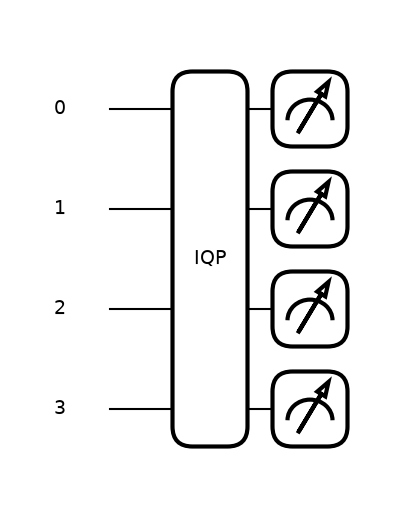

In [ ]:
# crate "lightning" device
dev = qp.device("lightning.qubit", wires=n_qubits)

@qp.qnode(dev)
def iqp_exact(weights, pattern):

    # use the IQP template
    qp.IQP(weights=weights, num_wires=n_qubits, pattern=pattern)

    # return the values of ZZII
    return qp.expval(qp.Z(0) @ qp.Z(1) @ qp.I(2) @ qp.I(3))

exp = iqp_exact(params, gates)
print(exp) # print exact expectation value

qp.draw_mpl(iqp_exact)(params, gates) # draw qnode


(<Figure size 1600x500 with 1 Axes>, <Axes: >)

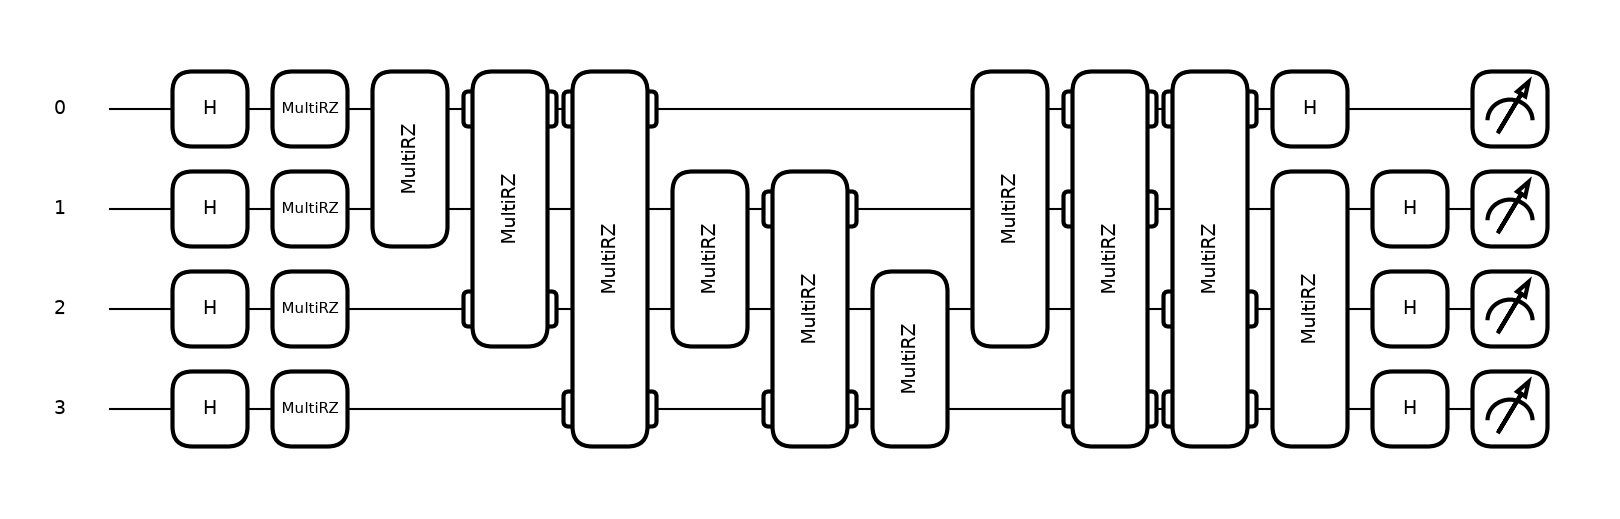

In [6]:
# decompose circuit into gates
iqp_decomp = qp.decompose(iqp_exact, gate_set=qp.gate_sets.ALL_QUBIT_OPS)
qp.draw_mpl(iqp_decomp)(params,gates) # draw circuit

*Sampling Circuit*

In [13]:
# set the number of shots [10]
@qp.set_shots(10)
@qp.qnode(dev)
def iqp_sample(weights, pattern):

    # use the IQP template
    qp.IQP(weights=weights, num_wires=n_qubits, pattern=pattern)

    # return the samples of ZZII
    return qp.sample(qp.Z(0) @ qp.Z(1) @ qp.I(2) @ qp.I(3))

# run qnode
samples = iqp_sample(params, gates)

print (samples) # print samples

[ 1. -1.  1.  1. -1.  1.  1. -1.  1.  1.]


*Classical Training*

In [14]:
# generate random parameters for gates
params = jax.random.uniform(key, shape=(len(gates),))

def expval_fn(params):
    expvals, stderr = qp.qnn.iqp_expval(observables,params,gates,n_qubits,n_samples,key)
    return expvals, stderr

# execute the expectation value computation (and standard errors for the estimates)
expvals, std_errs = expval_fn(params)
print("Expectation values:", expvals)

Expectation values: [ 0.0710061   0.01158807  0.37852818  0.639076   -0.02402977  0.08950658]


In [16]:
# define a loss function
def loss_fn(current_params):
    expvals, _ = expval_fn(current_params)

    # loss value
    loss_val = jnp.sum(expvals)

    return loss_val

# Train
# ---

# define the optimizer we want to work with
opt = optax.adam(learning_rate=0.3)

# define update step
@jax.jit
def update_step_jit(i, args):
    params, opt_state = args

    # find the new parameters based on the previous loss and gradients
    loss_val, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

    # print the loss every 5 steps
    def print_fn():
        jax.debug.print("Step: {i}  Loss: {loss_val}", i=i, loss_val=loss_val)

    jax.lax.cond((jnp.mod(i, 5) == 0), print_fn, lambda: None)

    return (params, opt_state)

# define higher-level optimization loop
@jax.jit
def optimization_jit(params):
    opt_state = opt.init(params)
    args = (params, opt_state)
    (params, opt_state) = jax.lax.fori_loop(0, 100, update_step_jit, args)

    return params

# run optimizer
final_params = optimization_jit(params)

print("-----------")
print("Optimized parameters:", final_params)
print("-----------")

# calculate the expected values with optimized parameters
expvals, std_errs = expval_fn(final_params)
print("Expectation values:", expvals)

Step: 0  Loss: 1.165675163269043
Step: 5  Loss: -1.2249191999435425
Step: 10  Loss: -1.323217511177063
Step: 15  Loss: -1.6130284070968628
Step: 20  Loss: -1.8089087009429932
Step: 25  Loss: -1.9462565183639526
Step: 30  Loss: -1.9449411630630493
Step: 35  Loss: -1.9589979648590088
Step: 40  Loss: -1.9820489883422852
Step: 45  Loss: -1.9936777353286743
Step: 50  Loss: -1.9957503080368042
Step: 55  Loss: -1.9978137016296387
Step: 60  Loss: -1.9976425170898438
Step: 65  Loss: -1.9987046718597412
Step: 70  Loss: -1.9995126724243164
Step: 75  Loss: -1.999993085861206
Step: 80  Loss: -2.0004801750183105
Step: 85  Loss: -2.000708818435669
Step: 90  Loss: -2.0008797645568848
Step: 95  Loss: -2.000946283340454
-----------
Optimized parameters: [-0.39477804  1.175811   -0.39461303  0.3946649   0.6373889  -0.39334825
 -0.9179018  -0.13108416  1.9743152   0.90938574 -0.39334488  1.9634992
  1.9654212   1.9661249 ]
-----------
Expectation values: [-0.74319583  0.00929748 -0.26644555 -0.2666352   0

*Resource Estimation*

In [17]:
import pennylane.estimator as qre
iqp = qre.IQP(num_wires=4,pattern=[[[0]], [[1]], [[2]], [[3]]])
print(qre.estimate(iqp))

--- Resources: ---
 Total wires: 4
   algorithmic wires: 4
   allocated wires: 0
     zero state: 0
     any state: 0
 Total gates : 184
   'T': 176,
   'CNOT': 0,
   'Hadamard': 8
